# Label 信息分析与可视化

这个 notebook 用来读取 Excel 标签文件，快速查看 label 的分布、缺失值、基础统计，并导出清洗后的结果。

使用方式：
1. 修改下面的 `xlsx_path`
2. 从上到下依次运行
3. 查看输出图和导出的统计文件

In [10]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print('seaborn available:', HAS_SEABORN)

seaborn available: True


In [11]:
xlsx_path = Path('/workspace/data/suwabe_label.xlsx')
output_dir = xlsx_path.parent / 'label_analysis_output'
output_dir.mkdir(parents=True, exist_ok=True)

print('xlsx_path =', xlsx_path)
print('output_dir =', output_dir)

if not xlsx_path.exists():
    candidates = sorted(set(Path('/workspace').rglob('*.xlsx')))
    print('File not found. Available xlsx files:')
    for path in candidates:
        print(' -', path)
    raise FileNotFoundError(f'找不到 Excel 文件: {xlsx_path}')

xlsx_path = /workspace/data/suwabe_label.xlsx
output_dir = /workspace/data/label_analysis_output


In [12]:
excel_file = pd.ExcelFile(xlsx_path)
print('工作表名称:', excel_file.sheet_names)
print('工作表数量:', len(excel_file.sheet_names))

sheet_name = excel_file.sheet_names[0]
df_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)

print('使用工作表:', sheet_name)
print('数据形状:', df_raw.shape)
print('列名:', list(df_raw.columns))
print('前 5 行:')
display(df_raw.head())

工作表名称: ['諏訪部', 'Sheet1']
工作表数量: 2
使用工作表: 諏訪部
数据形状: (48, 9)
列名: ['ID', 'ねじり', '姿勢', '脱力', '総合', 'Unnamed: 5', '評価に影響した要因', '評価とあまり関係なかった要因', 'Unnamed: 8']
前 5 行:


,ID,ねじり,姿勢,脱力,総合,Unnamed: 5,評価に影響した要因,評価とあまり関係なかった要因,Unnamed: 8
0,1,3,3,3,3,9.0,軸がまっすぐ、腕の脱力がわかる、テンポが安定。全体のバランスが良い,ねじり角度は大きくないかもしれないが、無理がない印象で高評価,NaN
1,2,2,2,3,2,7.0,ねじりが小さい。姿勢で左右差がある。左回転の際、若干後傾,脱力はできていると思うが、高評価に繋がらず。,NaN
2,3,3,3,3,3,9.0,全体的に良い。,しいていうと、形を気にしすぎて脱力しきっていない感じがあるが、３段階評価には影響なし,NaN
3,4,2,2,2,2,6.0,テンポに合わせようとして脱力できていない。姿勢が左回転のときに乱れる,脱力だけみると悪くないかもしれないが、全体として普通以下の印象,後半にかけて動きが改善
4,5,2,3,3,2,8.0,やや控えめなのか、ねじり小さく、思い切りできていない。動作が安定しない,回転で左右差があるが姿勢は３評価,NaN


In [13]:
print('字段结构:')
column_summary = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': df_raw.dtypes.astype(str).values,
    'non_null': df_raw.notna().sum().values,
    'null_count': df_raw.isna().sum().values,
    'nunique': [df_raw[col].nunique(dropna=True) for col in df_raw.columns],
})
display(column_summary)

print('基础信息:')
df_raw.info()

# 自动识别可视化的评分/标签列
id_candidates = [col for col in df_raw.columns if str(col).strip().lower() in {'id', 'index', 'no', 'num'}]
numeric_columns = [col for col in df_raw.columns if pd.api.types.is_numeric_dtype(df_raw[col])]
label_columns = [
    col for col in numeric_columns
    if col not in id_candidates and not str(col).startswith('Unnamed')
]

if not label_columns:
    low_cardinality_columns = [
        col for col in df_raw.columns
        if col not in id_candidates and not str(col).startswith('Unnamed')
        and df_raw[col].nunique(dropna=True) <= max(10, len(df_raw) // 2)
    ]
    label_columns = low_cardinality_columns

text_columns = [col for col in df_raw.columns if df_raw[col].dtype == 'object']

print('识别到的 ID 列:', id_candidates)
print('识别到的 label 列:', label_columns)
print('识别到的文本列:', text_columns)

字段结构:


,column,dtype,non_null,null_count,nunique
0,ID,int64,48,0,45
1,ねじり,int64,48,0,6
2,姿勢,int64,48,0,5
3,脱力,int64,48,0,6
4,総合,int64,48,0,6
5,Unnamed: 5,float64,45,3,6
6,評価に影響した要因,object,45,3,42
7,評価とあまり関係なかった要因,object,27,21,24
8,Unnamed: 8,object,4,44,3


基础信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              48 non-null     int64  
 1   ねじり             48 non-null     int64  
 2   姿勢              48 non-null     int64  
 3   脱力              48 non-null     int64  
 4   総合              48 non-null     int64  
 5   Unnamed: 5      45 non-null     float64
 6   評価に影響した要因       45 non-null     object 
 7   評価とあまり関係なかった要因  27 non-null     object 
 8   Unnamed: 8      4 non-null      object 
dtypes: float64(1), int64(5), object(3)
memory usage: 3.5+ KB
识别到的 ID 列: ['ID']
识别到的 label 列: ['ねじり', '姿勢', '脱力', '総合']
识别到的文本列: ['評価に影響した要因', '評価とあまり関係なかった要因', 'Unnamed: 8']


In [14]:
df = df_raw.copy()

# 统一字符串格式，清理前后空格与全角空格
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = (
            df[col]
            .astype('string')
            .str.replace('\u3000', ' ', regex=False)
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

for col in label_columns:
    df[col] = df[col].astype('string').str.strip()

before_dedup = len(df)
df = df.drop_duplicates().copy()
removed_duplicates = before_dedup - len(df)

print('清洗前行数:', len(df_raw))
print('去重后行数:', len(df))
print('重复去除数量:', removed_duplicates)
display(df.head())

清洗前行数: 48
去重后行数: 48
重复去除数量: 0


,ID,ねじり,姿勢,脱力,総合,Unnamed: 5,評価に影響した要因,評価とあまり関係なかった要因,Unnamed: 8
0,1,3,3,3,3,9.0,軸がまっすぐ、腕の脱力がわかる、テンポが安定。全体のバランスが良い,ねじり角度は大きくないかもしれないが、無理がない印象で高評価,<NA>
1,2,2,2,3,2,7.0,ねじりが小さい。姿勢で左右差がある。左回転の際、若干後傾,脱力はできていると思うが、高評価に繋がらず。,<NA>
2,3,3,3,3,3,9.0,全体的に良い。,しいていうと、形を気にしすぎて脱力しきっていない感じがあるが、３段階評価には影響なし,<NA>
3,4,2,2,2,2,6.0,テンポに合わせようとして脱力できていない。姿勢が左回転のときに乱れる,脱力だけみると悪くないかもしれないが、全体として普通以下の印象,後半にかけて動きが改善
4,5,2,3,3,2,8.0,やや控えめなのか、ねじり小さく、思い切りできていない。動作が安定しない,回転で左右差があるが姿勢は３評価,<NA>


In [15]:
if not label_columns:
    raise ValueError('没有找到可用的 label 列，请手动指定 label_columns。')

label_stats = []
label_counts_map = {}

for col in label_columns:
    counts = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis('label')
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    counts['ratio'] = counts['count'] / counts['count'].sum()
    counts['column'] = col
    label_counts_map[col] = counts
    label_stats.append({
        'column': col,
        'unique_labels': int(df[col].nunique(dropna=True)),
        'non_null': int(df[col].notna().sum()),
        'missing': int(df[col].isna().sum()),
        'top_label': None if counts.empty else counts.iloc[0]['label'],
        'top_count': 0 if counts.empty else int(counts.iloc[0]['count']),
    })

label_summary = pd.DataFrame(label_stats)
print('标签列概览:')
display(label_summary)

for col, counts in label_counts_map.items():
    print(f'[{col}] 分布:')
    display(counts)

unique_label_total = sum(item['unique_labels'] for item in label_stats)
print('标签列数量:', len(label_columns))
print('标签唯一值总数:', unique_label_total)

标签列概览:


,column,unique_labels,non_null,missing,top_label,top_count
0,ねじり,6,48,0,2,28
1,姿勢,5,48,0,2,23
2,脱力,6,48,0,3,20
3,総合,6,48,0,2,22


[ねじり] 分布:


,label,count,ratio,column
0,2,28,0.583333,ねじり
1,3,11,0.229167,ねじり
2,1,6,0.125,ねじり
3,11,1,0.020833,ねじり
4,28,1,0.020833,ねじり
5,6,1,0.020833,ねじり


[姿勢] 分布:


...

[脱力] 分布:


,label,count,ratio,column
0,3,20,0.416667,脱力
1,2,17,0.354167,脱力
2,1,8,0.166667,脱力
3,20,1,0.020833,脱力
4,17,1,0.020833,脱力
5,8,1,0.020833,脱力


[総合] 分布:


,label,count,ratio,column
0,2,22,0.458333,総合
1,3,14,0.291667,総合
2,1,9,0.1875,総合
3,14,1,0.020833,総合
4,22,1,0.020833,総合
5,9,1,0.020833,総合


标签列数量: 4
标签唯一值总数: 23


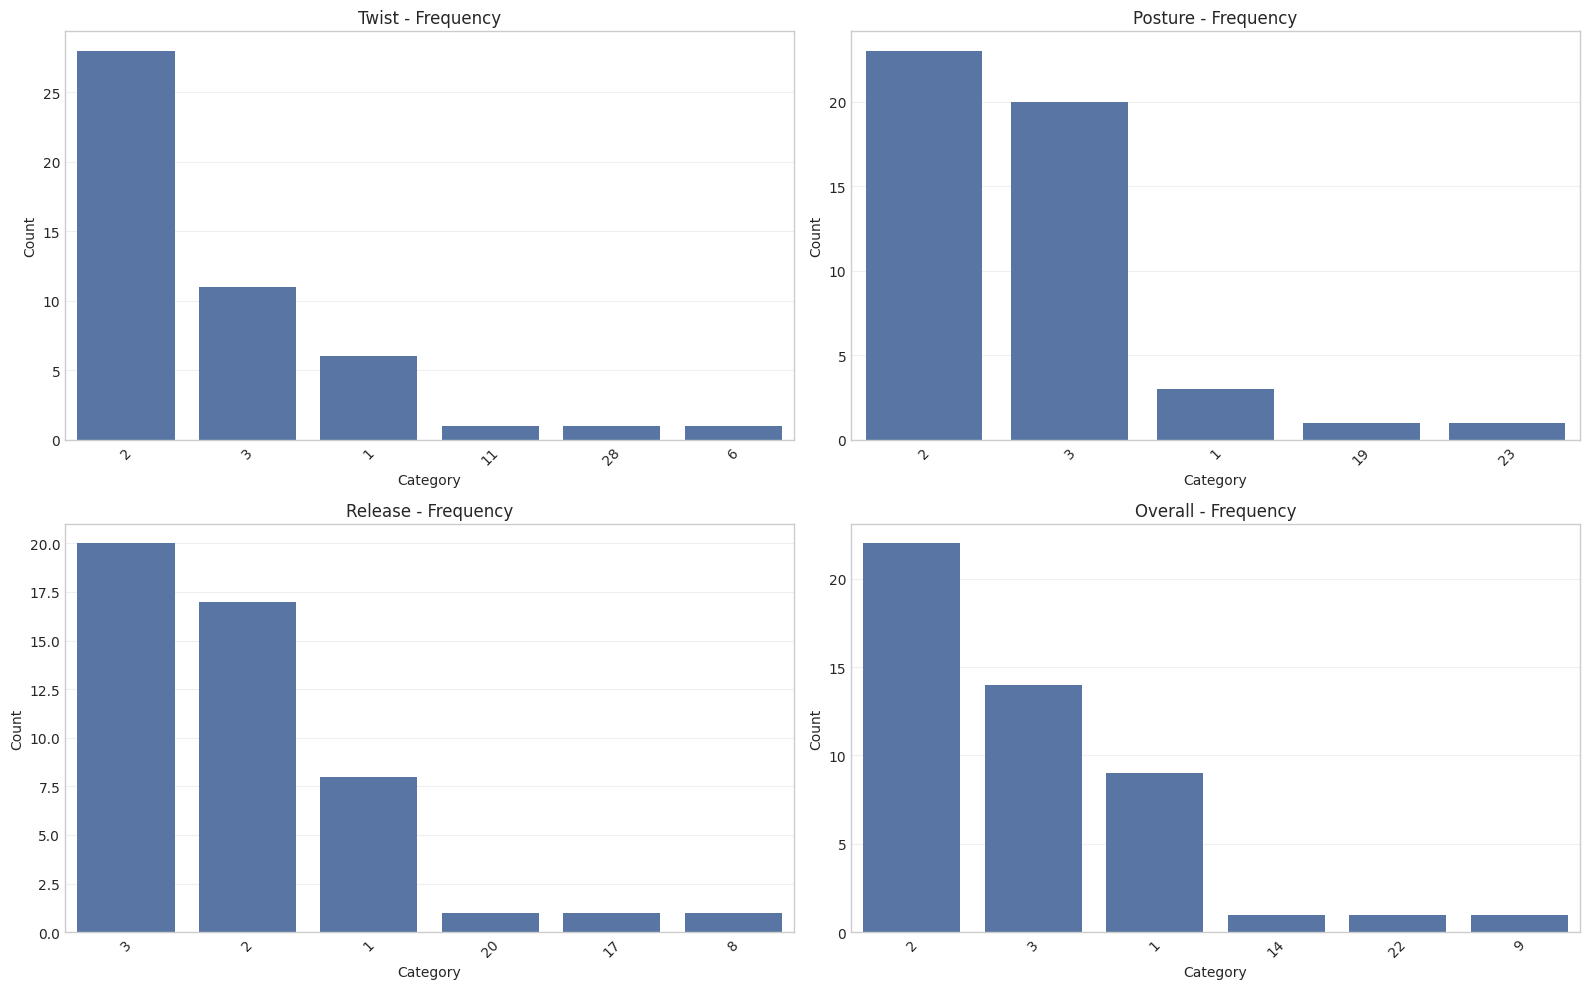

In [16]:
n_cols = 2
n_rows = int(np.ceil(len(label_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.array(axes).reshape(-1)

column_title_map = {
    'ねじり': 'Twist',
    '姿勢': 'Posture',
    '脱力': 'Release',
    '総合': 'Overall',
}

for idx, col in enumerate(label_columns):
    ax = axes[idx]
    plot_df = label_counts_map[col].sort_values('count', ascending=False)
    title_name = column_title_map.get(col, str(col))

    if HAS_SEABORN:
        sns.barplot(data=plot_df, x='label', y='count', ax=ax, color='#4C72B0')
    else:
        ax.bar(plot_df['label'].astype(str), plot_df['count'], color='#4C72B0')

    ax.set_title(f'{title_name} - Frequency')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', alpha=0.3)

for ax in axes[len(label_columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
print('缺失值统计:')
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_ratio': df.isna().mean(),
    'dtype': df.dtypes.astype(str),
}).sort_values('missing_count', ascending=False)
display(missing_summary[missing_summary['missing_count'] > 0])

print('低频类别检查:')
for col in label_columns:
    rare = label_counts_map[col][label_counts_map[col]['count'] <= 2]
    print(f'[{col}] count <= 2 的类别数: {len(rare)}')
    if len(rare) > 0:
        display(rare)

print('重复记录数量（清洗后）:', int(df.duplicated().sum()))

缺失值统计:


,missing_count,missing_ratio,dtype
Unnamed: 8,44,0.916667,string
評価とあまり関係なかった要因,21,0.437500,string
Unnamed: 5,3,0.062500,float64
評価に影響した要因,3,0.062500,string


低频类别检查:
[ねじり] count <= 2 的类别数: 3


,label,count,ratio,column
3,11,1,0.020833,ねじり
4,28,1,0.020833,ねじり
5,6,1,0.020833,ねじり


[姿勢] count <= 2 的类别数: 2


...

[脱力] count <= 2 的类别数: 3


,label,count,ratio,column
3,20,1,0.020833,脱力
4,17,1,0.020833,脱力
5,8,1,0.020833,脱力


[総合] count <= 2 的类别数: 3


,label,count,ratio,column
3,14,1,0.020833,総合
4,22,1,0.020833,総合
5,9,1,0.020833,総合


重复记录数量（清洗后）: 0


In [18]:
stats_path = output_dir / 'label_summary.csv'
counts_path = output_dir / 'label_value_counts_long.csv'
clean_path = output_dir / 'label_data_cleaned.csv'
missing_path = output_dir / 'missing_summary.csv'

label_summary.to_csv(stats_path, index=False, encoding='utf-8-sig')
pd.concat(label_counts_map.values(), ignore_index=True).to_csv(counts_path, index=False, encoding='utf-8-sig')
df.to_csv(clean_path, index=False, encoding='utf-8-sig')
missing_summary.to_csv(missing_path, encoding='utf-8-sig')

print('已导出:')
print(' -', stats_path)
print(' -', counts_path)
print(' -', clean_path)
print(' -', missing_path)

已导出:
 - /workspace/data/label_analysis_output/label_summary.csv
 - /workspace/data/label_analysis_output/label_value_counts_long.csv
 - /workspace/data/label_analysis_output/label_data_cleaned.csv
 - /workspace/data/label_analysis_output/missing_summary.csv


## 运行结果说明

- 图表会直接显示在 notebook 中。
- 导出的文件保存在 `label_analysis_output/` 下。
- 如果 Excel 文件不在默认路径，请修改第 3 个单元里的 `xlsx_path`。